Toward Data Science!

In [1]:
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

e:\miniconda\envs\marketing_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from data_generator import data_generator as dg

# Set parameters for data generator
start_date = "2021-01-01"
periods = 52 * 3
channels = ["tv", "social", "search"]
adstock_alphas = [0.50, 0.25, 0.05]
saturation_lamdas = [1.5, 2.5, 3.5]
betas = [350, 150, 50]
spend_scalars = [10, 15, 20]

df = dg(start_date, periods, channels, spend_scalars, adstock_alphas, saturation_lamdas, betas)

In [5]:
import numpy as np
# Scale betas using maximum sales value - this is so it is comparable to the fitted beta from pymc (pymc does feature and target scaling using MaxAbsScaler from sklearn)
betas_scaled = [
    ((df["tv_sales"] / df["sales"].max()) / df["tv_saturated"]).mean(),
    ((df["social_sales"] / df["sales"].max()) / df["social_saturated"]).mean(),
    ((df["search_sales"] / df["sales"].max()) / df["search_saturated"]).mean()
]

# Calculate contributions
contributions = np.asarray([
    round((df["tv_sales"].sum() / df["sales"].sum()), 2),
    round((df["social_sales"].sum() / df["sales"].sum()), 2),
    round((df["search_sales"].sum() / df["sales"].sum()), 2),
    round((df["demand"].sum() / df["sales"].sum()), 2)
])

df[["date", "demand", "demand_proxy", "tv_spend_raw", "social_spend_raw", "search_spend_raw", "sales"]]

,date,demand,demand_proxy,tv_spend_raw,social_spend_raw,search_spend_raw,sales
0,2021-01-03,208.704821,227.219432,3280.453307,3534.178408,5148.526731,304.226863
1,2021-01-10,283.392196,259.929927,2893.807192,4667.658397,2786.781147,404.308004
2,2021-01-17,194.237167,235.956709,2150.779290,2346.476275,3926.175894,301.749865
3,2021-01-24,91.925177,93.808275,1345.898926,1073.272395,900.905877,160.581923
4,2021-01-31,295.582653,298.600774,4884.618877,3436.769150,2268.030924,425.223189
...,...,...,...,...,...,...,...
151,2023-11-26,335.038832,300.208436,3413.856403,5117.149148,5710.302207,552.362202
152,2023-12-03,505.982206,434.403733,4568.708541,7215.349991,17168.873789,747.074761
153,2023-12-10,470.315876,431.585864,4028.884561,7884.223651,8450.370191,697.117929
154,2023-12-17,597.219125,682.027737,4182.124063,2624.640642,5910.583823,775.084446


In [3]:
import pandas as pd

from pymc_marketing.mmm import (
    GeometricAdstock,
    LogisticSaturation,
    MMM,
)


mmm = MMM(
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    date_column="date_week",
    channel_columns=["x1", "x2"],
    control_columns=[
        "event_1",
        "event_2",
        "t",
    ],
    yearly_seasonality=2,
)

e:\miniconda\envs\marketing_env\Lib\site-packages\pydantic\_internal\_validate_call.py:137: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our documentation has been updated to reflect this change.
            Refer to the migration guide for more details: https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_migration_guide.html
            
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


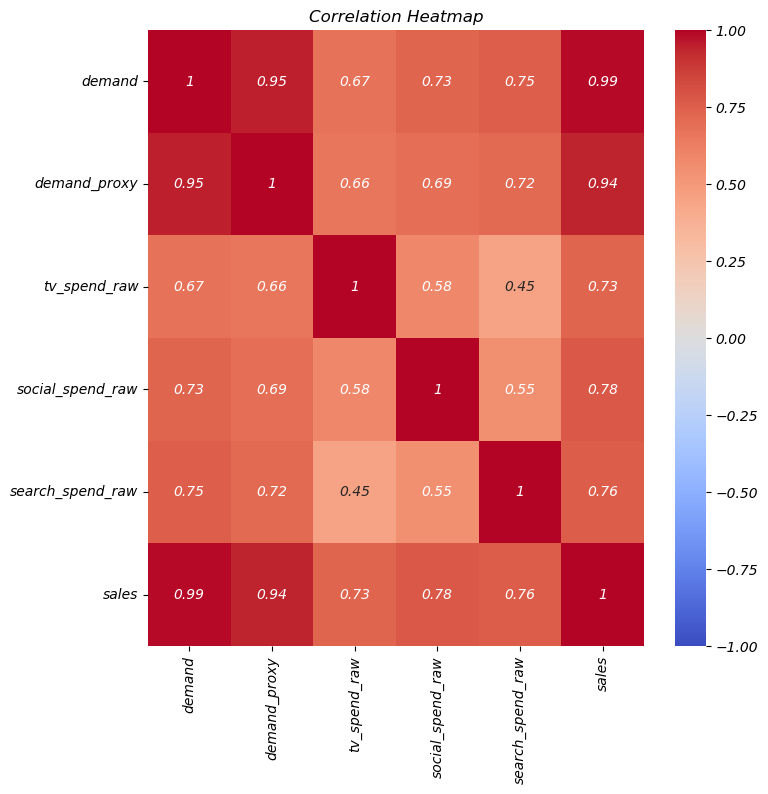

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 8))
sns.heatmap(df[["demand", "demand_proxy", "tv_spend_raw", "social_spend_raw", "search_spend_raw", "sales"]].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()



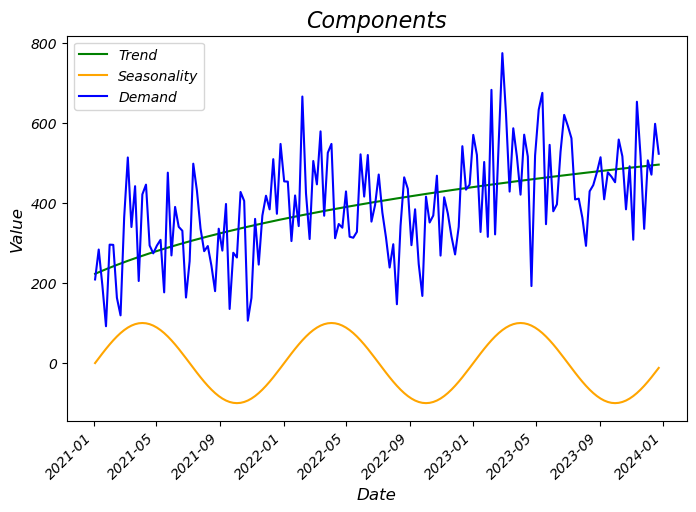

In [7]:


plt.figure(figsize=(8, 5))

sns.lineplot(x=df['date'], y=df['trend']*1000, label="Trend", color="green")
sns.lineplot(x=df['date'], y=df['seasonality']*1000, label="Seasonality", color="orange")
sns.lineplot(x=df['date'], y=df['demand'], label="Demand", color="blue")

plt.title('Components', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()



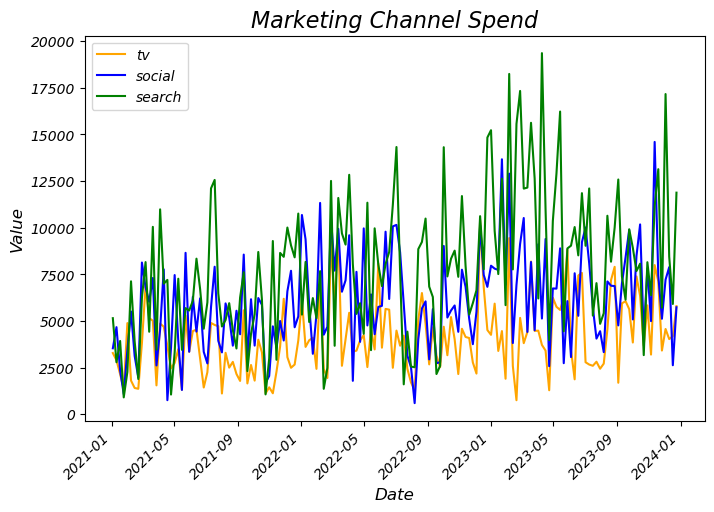

In [8]:
plt.figure(figsize=(8, 5))

sns.lineplot(x=df['date'], y=df['tv_spend_raw'], label=channels[0], color="orange")
sns.lineplot(x=df['date'], y=df['social_spend_raw'], label=channels[1], color="blue")
sns.lineplot(x=df['date'], y=df['search_spend_raw'], label=channels[2], color="green")
plt.title('Marketing Channel Spend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()



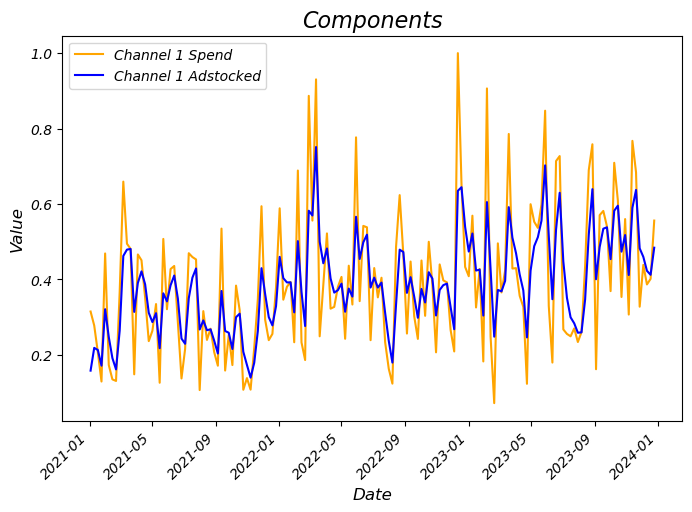

In [9]:
plt.figure(figsize=(8, 5))

sns.lineplot(x=df['date'], y=df['tv_spend'], label="Channel 1 Spend", color="orange")
sns.lineplot(x=df['date'], y=df['tv_adstock'], label="Channel 1 Adstocked", color="blue")

plt.title('Components', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

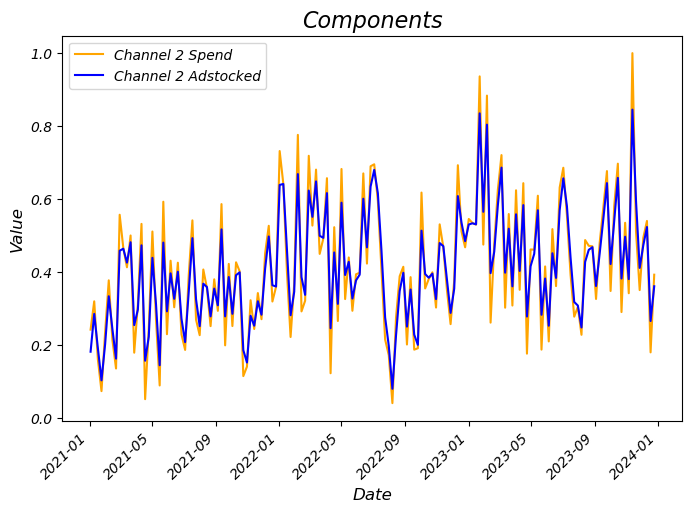

In [10]:


plt.figure(figsize=(8, 5))

sns.lineplot(x=df['date'], y=df['social_spend'], label="Channel 2 Spend", color="orange")
sns.lineplot(x=df['date'], y=df['social_adstock'], label="Channel 2 Adstocked", color="blue")

plt.title('Components', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()



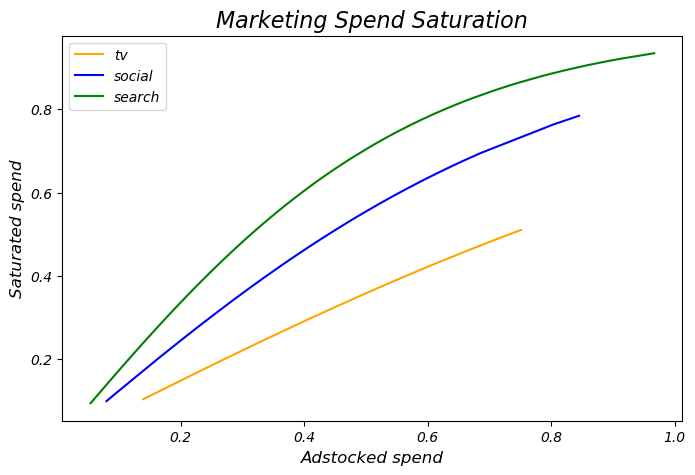

In [11]:
plt.figure(figsize=(8, 5))

sns.lineplot(x=df['tv_adstock'], y=df['tv_saturated'], label=channels[0], color="orange")
sns.lineplot(x=df['social_adstock'], y=df['social_saturated'], label=channels[1], color="blue")
sns.lineplot(x=df['search_adstock'], y=df['search_saturated'], label=channels[2], color="green")

plt.title('Marketing Spend Saturation', fontsize=16)
plt.xlabel('Adstocked spend', fontsize=12)
plt.ylabel('Saturated spend', fontsize=12)
plt.legend()
plt.show()



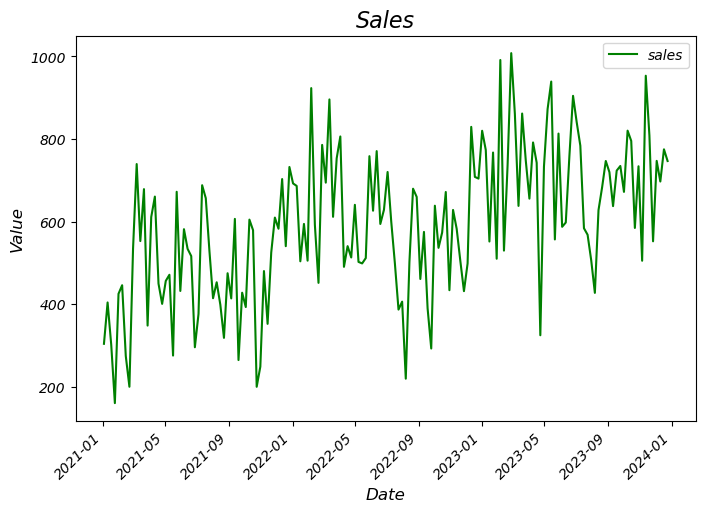

In [12]:


plt.figure(figsize=(8, 5))

sns.lineplot(x=df['date'], y=df['sales'], label="sales", color="green")

plt.title('Sales', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()



In [ ]:

dummy_model = MMM(
    date_column="",
    channel_columns=[""],
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
)
dummy_model.default_model_config



e:\miniconda\envs\marketing_env\Lib\site-packages\pydantic\_internal\_validate_call.py:137: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our documentation has been updated to reflect this change.
            Refer to the migration guide for more details: https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_migration_guide.html
            
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

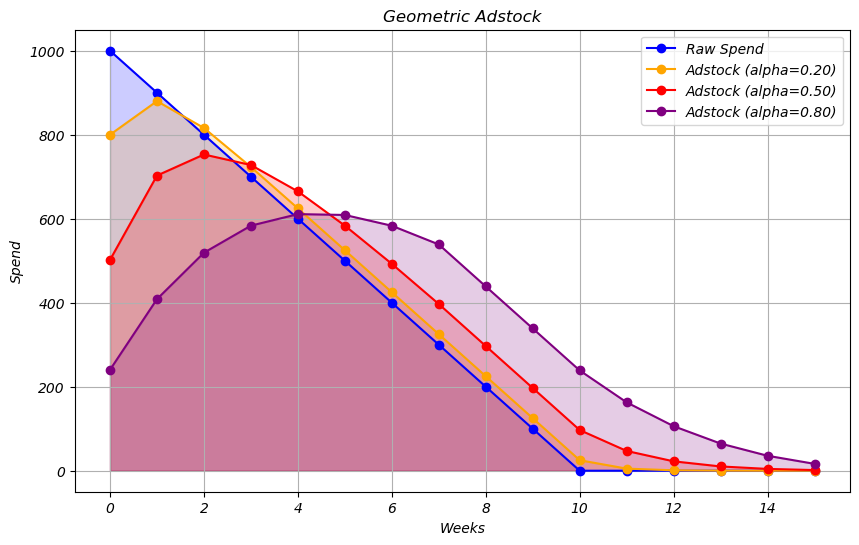

In [16]:
import pytensor.tensor as pt
import pytensor.xtensor as ptx

raw_spend = np.array([1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 0, 0, 0, 0, 0, 0])

spend = ptx.as_xtensor(pt.as_tensor_variable(raw_spend), dims=('time',))

adstock_spend_1 = geometric_adstock(x=spend, alpha=0.20, l_max=8, normalize=True, dim='time').eval().flatten()
adstock_spend_2 = geometric_adstock(x=spend, alpha=0.50, l_max=8, normalize=True, dim='time').eval().flatten()
adstock_spend_3 = geometric_adstock(x=spend, alpha=0.80, l_max=8, normalize=True, dim='time').eval().flatten()

plt.figure(figsize=(10, 6))

plt.plot(raw_spend, marker='o', label='Raw Spend', color='blue')
plt.fill_between(range(len(raw_spend)), 0, raw_spend, color='blue', alpha=0.2)

plt.plot(adstock_spend_1, marker='o', label='Adstock (alpha=0.20)', color='orange')
plt.fill_between(range(len(adstock_spend_1)), 0, adstock_spend_1, color='orange', alpha=0.2)

plt.plot(adstock_spend_2, marker='o', label='Adstock (alpha=0.50)', color='red')
plt.fill_between(range(len(adstock_spend_2)), 0, adstock_spend_2, color='red', alpha=0.2)

plt.plot(adstock_spend_3, marker='o', label='Adstock (alpha=0.80)', color='purple')
plt.fill_between(range(len(adstock_spend_3)), 0, adstock_spend_3, color='purple', alpha=0.2)

plt.xlabel('Weeks')
plt.ylabel('Spend')
plt.title('Geometric Adstock')
plt.legend()
plt.grid(True)
plt.show()

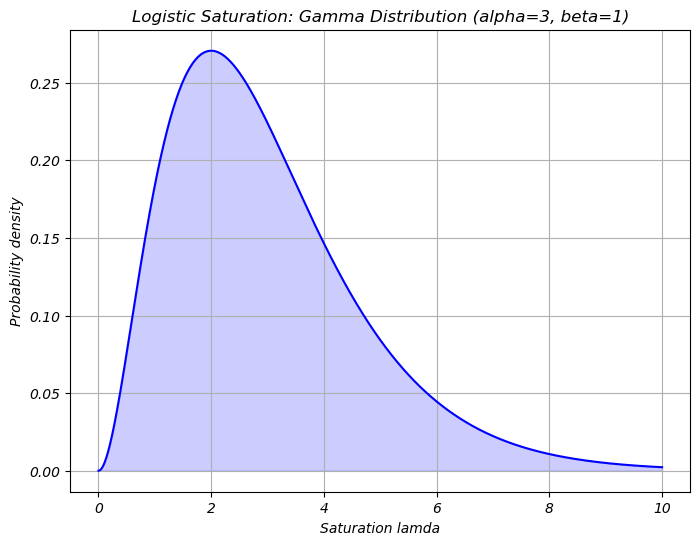

In [18]:
from scipy.stats import beta, gamma, halfnorm, laplace, norm, truncnorm
alpha = 3
beta = 1

x2 = np.linspace(0, 10, 1000)
y2 = gamma.pdf(x2, alpha, scale=1/beta)

plt.figure(figsize=(8, 6))
plt.plot(x2, y2, 'b-')
plt.fill_between(x2, y2, alpha=0.2, color='blue')
plt.title('Logistic Saturation: Gamma Distribution (alpha=3, beta=1)')
plt.xlabel('Saturation lamda')
plt.ylabel('Probability density')
plt.grid(True)
plt.show()

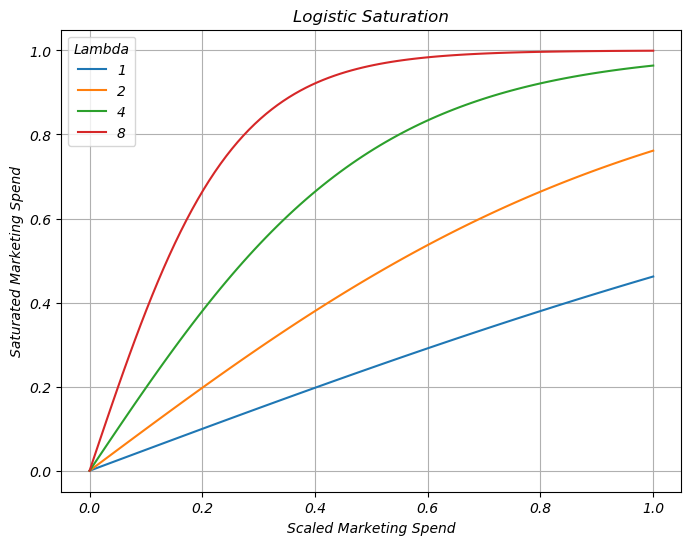

In [20]:

scaled_spend = np.linspace(start=0.0, stop=1.0, num=100)

spend = ptx.as_xtensor(pt.as_tensor_variable(scaled_spend), dims=('time',))

saturated_spend_1 = logistic_saturation(x=spend, lam=1).eval()
saturated_spend_2 = logistic_saturation(x=spend, lam=2).eval()
saturated_spend_4 = logistic_saturation(x=spend, lam=4).eval()
saturated_spend_8 = logistic_saturation(x=spend, lam=8).eval()

plt.figure(figsize=(8, 6))
sns.lineplot(x=scaled_spend, y=saturated_spend_1, label="1")
sns.lineplot(x=scaled_spend, y=saturated_spend_2, label="2")
sns.lineplot(x=scaled_spend, y=saturated_spend_4, label="4")
sns.lineplot(x=scaled_spend, y=saturated_spend_8, label="8")

plt.title('Logistic Saturation')
plt.xlabel('Scaled Marketing Spend')
plt.ylabel('Saturated Marketing Spend')
plt.legend(title='Lambda')
plt.grid(True)
plt.show()



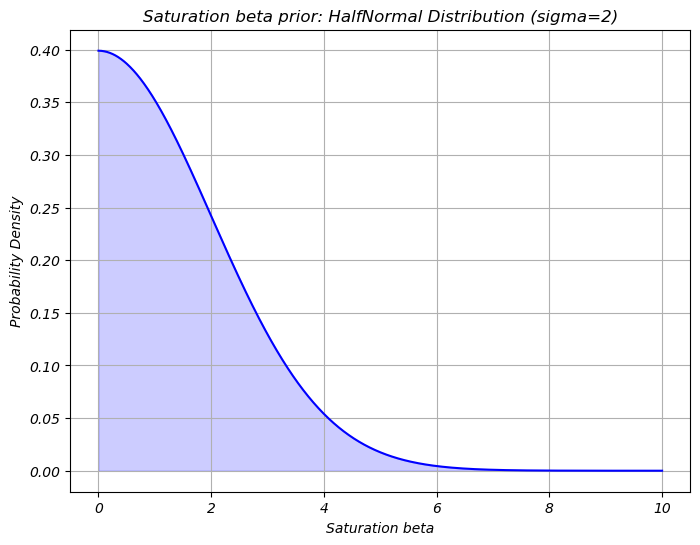

In [21]:
sigma = 2

x3 = np.linspace(0, 10, 1000)
y3 = halfnorm.pdf(x3, scale=sigma)

plt.figure(figsize=(8, 6))
plt.plot(x3, y3, 'b-')
plt.fill_between(x3, y3, alpha=0.2, color='blue')
plt.title('Saturation beta prior: HalfNormal Distribution (sigma=2)')
plt.xlabel('Saturation beta')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Fit model

In [22]:


df.info()



<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              156 non-null    datetime64[us]
 1   trend             156 non-null    float64       
 2   seasonality       156 non-null    float64       
 3   demand            156 non-null    float64       
 4   demand_proxy      156 non-null    float64       
 5   sales             156 non-null    float64       
 6   tv_spend_raw      156 non-null    float64       
 7   tv_spend          156 non-null    float64       
 8   tv_adstock        156 non-null    float64       
 9   tv_saturated      156 non-null    float64       
 10  tv_sales          156 non-null    float64       
 11  social_spend_raw  156 non-null    float64       
 12  social_spend      156 non-null    float64       
 13  social_adstock    156 non-null    float64       
 14  social_saturated  156 non-null    flo

In [24]:
# set date column
date_col = "date"

# set outcome column
y_col = "sales"

# set marketing variables
channel_cols = ["tv_spend_raw",
                "social_spend_raw",
                "search_spend_raw"]

# set control variables
control_cols = ["demand_proxy"]

# create arrays
X = df[[date_col] + channel_cols + control_cols]
y = df[y_col]

# set test (out-of-sample) length
test_len = 8

# create train and test indexs
train_idx = slice(0, len(df) - test_len)
out_of_time_idx = slice(len(df) - test_len, len(df))

In [25]:
mmm_default = MMM(
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    date_column=date_col,
    channel_columns=channel_cols,
    control_columns=control_cols,
)

mmm_default.default_model_config

e:\miniconda\envs\marketing_env\Lib\site-packages\pydantic\_internal\_validate_call.py:137: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our documentation has been updated to reflect this change.
            Refer to the migration guide for more details: https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_migration_guide.html
            
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

In [26]:


fit_kwargs = {
    "tune": 1_000,
    "chains": 4,
    "draws": 1_000,
    "target_accept": 0.9,
}

mmm_default.fit(X[train_idx], y[train_idx], **fit_kwargs)



e:\miniconda\envs\marketing_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, adstock_alpha, saturation_lam, saturation_beta, gamma_control, y_sigma]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 145 seconds.


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data
	> fit_data

In [27]:
mmm_default.save("mmm_default.nc")

In [ ]:
mmm_default.idata["sample_stats"]["diverging"].sum().item()

# important, if there are divergencies

0

In [29]:
import arviz as az
az.summary(
    data=mmm_default.fit_result,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
    ],
)



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-0.011,0.024,-0.056,0.031,0.001,0.000,1925.0,2606.0,1.0
y_sigma,0.035,0.002,0.031,0.039,0.000,0.000,3404.0,2588.0,1.0
saturation_beta[tv_spend_raw],0.413,0.279,0.173,0.808,0.010,0.024,1097.0,955.0,1.0
saturation_beta[social_spend_raw],0.234,0.092,0.148,0.324,0.005,0.019,910.0,396.0,1.0
saturation_beta[search_spend_raw],0.288,0.234,0.073,0.659,0.007,0.015,1608.0,1176.0,1.0
saturation_lam[tv_spend_raw],2.325,1.080,0.332,4.098,0.032,0.017,1038.0,948.0,1.0
saturation_lam[social_spend_raw],3.203,0.965,1.234,4.932,0.034,0.029,892.0,423.0,1.0
saturation_lam[search_spend_raw],1.798,0.945,0.254,3.479,0.020,0.014,1771.0,1470.0,1.0
adstock_alpha[tv_spend_raw],0.446,0.081,0.299,0.596,0.002,0.002,2881.0,2104.0,1.0
adstock_alpha[social_spend_raw],0.127,0.088,0.000,0.288,0.002,0.001,2071.0,1819.0,1.0


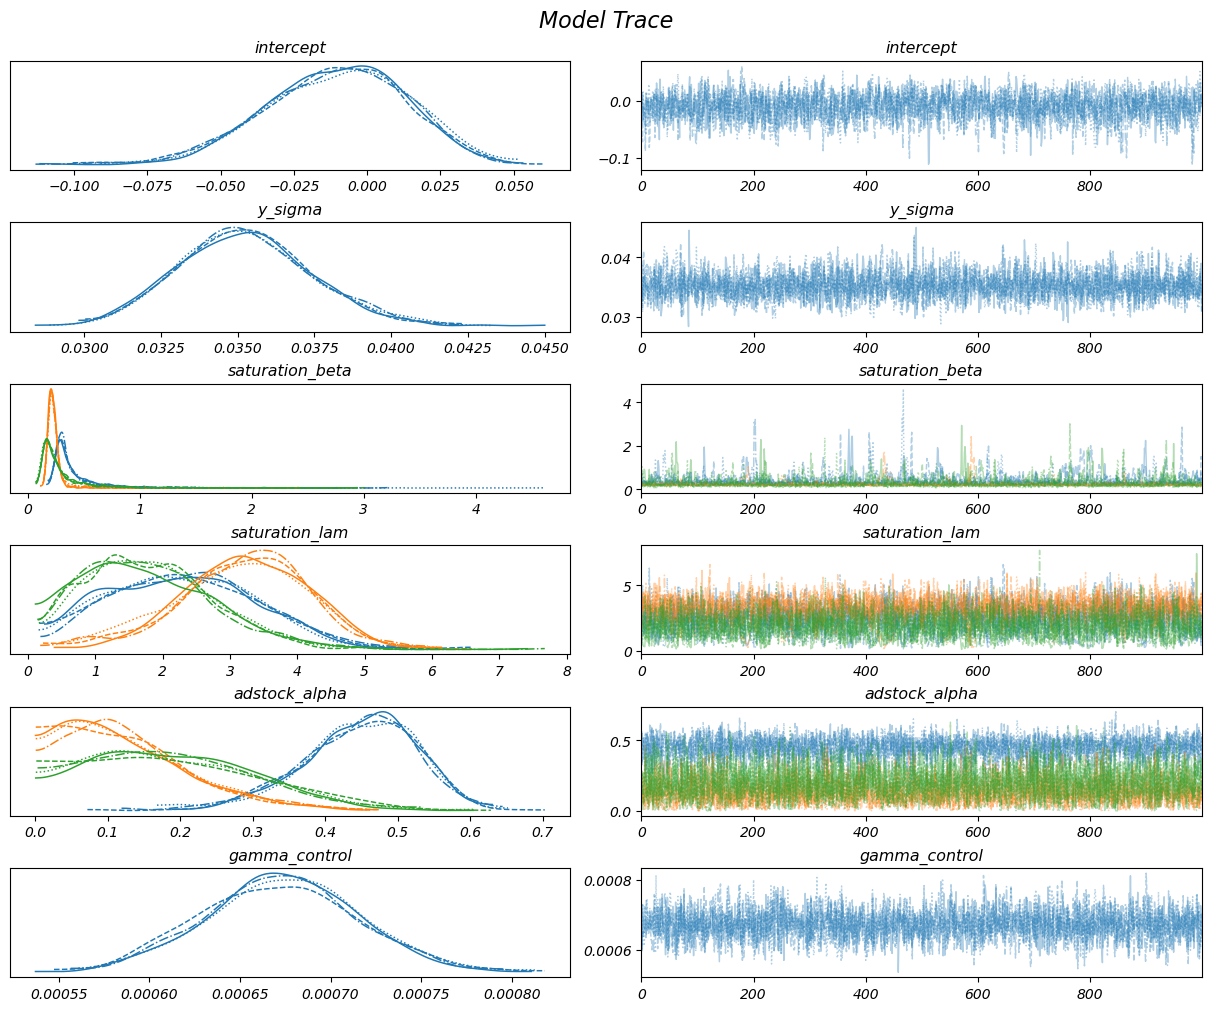

In [30]:

_ = az.plot_trace(
    data=mmm_default.fit_result,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16);



In [31]:
mmm_default.sample_posterior_predictive(X[train_idx], extend_idata=True, combined=True)



Sampling: [y]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


<xarray.Dataset> Size: 5MB
Dimensions:  (date: 148, sample: 4000)
Coordinates:
  * date     (date) datetime64[us] 1kB 2021-01-03 2021-01-10 ... 2023-10-29
  * sample   (sample) object 32kB MultiIndex
  * chain    (sample) int64 32kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 32kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y        (date, sample) float64 5MB 334.7 319.3 326.9 ... 703.8 620.7 709.6
Attributes:
    created_at:                 2026-06-14T16:14:02.118418+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5

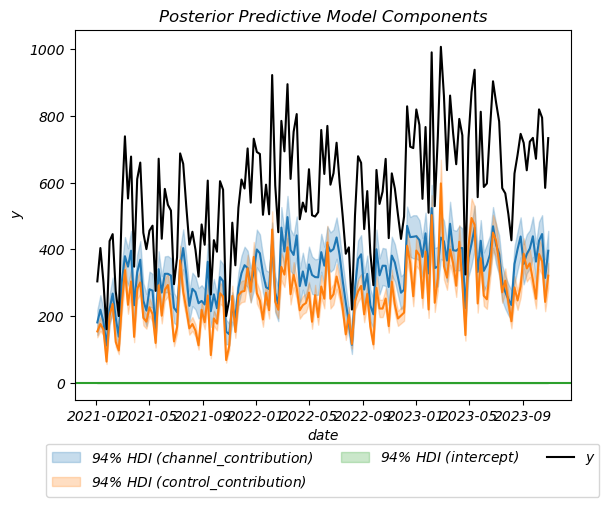

In [32]:

mmm_default.plot_components_contributions(original_scale=True);



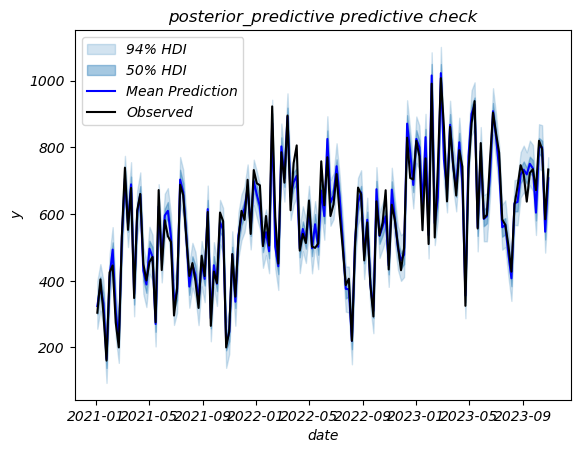

In [33]:
mmm_default.plot_posterior_predictive(original_scale=True);



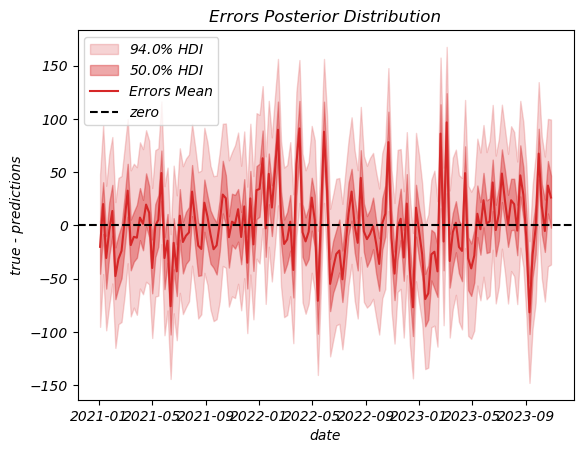

In [34]:


mmm_default.plot_errors(original_scale=True);



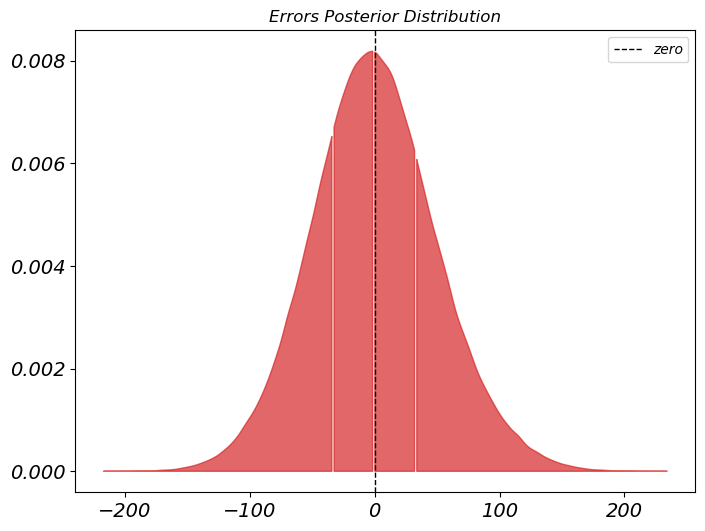

In [35]:


errors = mmm_default.get_errors(original_scale=True)

fig, ax = plt.subplots(figsize=(8, 6))
az.plot_dist(
    errors, quantiles=[0.25, 0.5, 0.75], color="C3", fill_kwargs={"alpha": 0.7}, ax=ax
)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="zero")
ax.legend()
ax.set(title="Errors Posterior Distribution");



In [69]:


y_out_of_sample = mmm_default.sample_posterior_predictive(
    X_pred=X[out_of_time_idx], extend_idata=False, include_last_observations=True
)

def plot_in_sample(X, y, ax, n_points: int = 15):
    (
        y.to_frame()
        .set_index(X[date_col])
        .iloc[-n_points:]
        .plot(ax=ax, marker="o", color="black", label="actuals")
    )
    return ax


def plot_out_of_sample(X_out_of_sample, y_out_of_sample, ax, color, label):
    y_out_of_sample_groupby = y_out_of_sample["y"].to_series().groupby("date")
    
    lower, upper = quantiles = [0.025, 0.975]
    conf = y_out_of_sample_groupby.quantile(quantiles).unstack()
    
    dates = X_out_of_sample[date_col].values.astype("datetime64[ms]")  # ← fix
    
    ax.fill_between(
        dates,
        conf[lower].values,
        conf[upper].values,
        alpha=0.25,
        color=color,
        label=f"{label} interval",
    )
    
    mean = y_out_of_sample_groupby.mean()
    mean.index = mean.index.astype("datetime64[ms]")  # ← mismo fix para mean
    mean.plot(ax=ax, marker="o", label=label, color=color, linestyle="--")
    
    ax.set(ylabel="Original Target Scale", title="Out of sample predictions for MMM")
    return ax





Sampling: [y]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


In [72]:
plot_out_of_sample(
    X[out_of_time_idx], y_out_of_sample, ax=ax, label="out of sample", color="C0"
)

<Axes: title={'center': 'Out of sample predictions for MMM'}, xlabel='date', ylabel='Original Target Scale'>

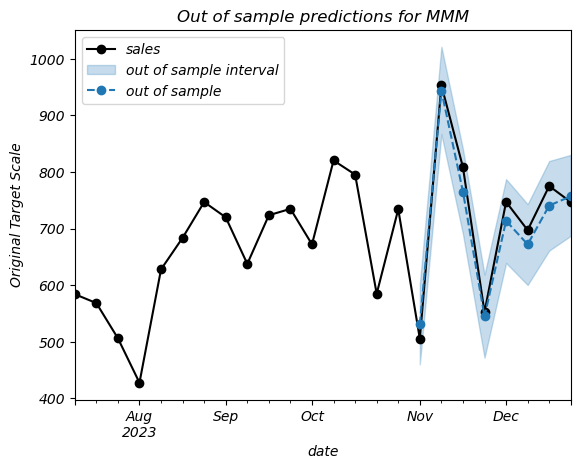

In [73]:
_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax, n_points=len(X[out_of_time_idx])*3)
plot_out_of_sample(
    X[out_of_time_idx], y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
ax.legend(loc="upper left");

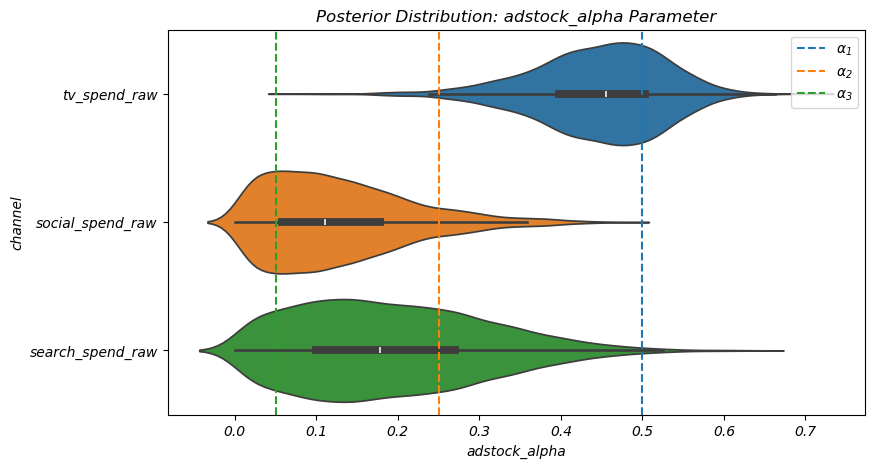

In [74]:
fig = mmm_default.plot_channel_parameter(param_name="adstock_alpha", figsize=(9, 5))
ax = fig.axes[0]
ax.axvline(x=adstock_alphas[0], color="C0", linestyle="--", label=r"$\alpha_1$")
ax.axvline(x=adstock_alphas[1], color="C1", linestyle="--", label=r"$\alpha_2$")
ax.axvline(x=adstock_alphas[2], color="C2", linestyle="--", label=r"$\alpha_3$")
ax.legend(loc="upper right");



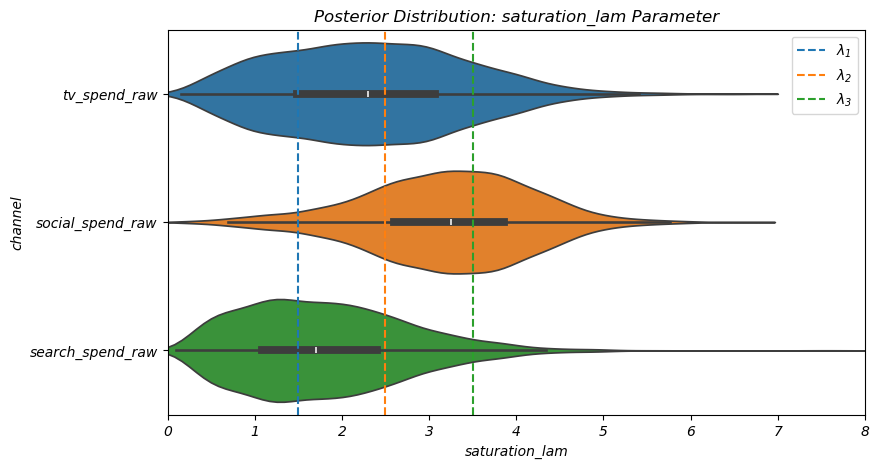

In [75]:
fig = mmm_default.plot_channel_parameter(param_name="saturation_lam", figsize=(9, 5))
ax = fig.axes[0]
ax.axvline(x=saturation_lamdas[0], color="C0", linestyle="--", label=r"$\lambda_1$")
ax.axvline(x=saturation_lamdas[1], color="C1", linestyle="--", label=r"$\lambda_2$")
ax.axvline(x=saturation_lamdas[2], color="C2", linestyle="--", label=r"$\lambda_3$")
ax.set_xlim([0, 8])
ax.legend(loc="upper right");

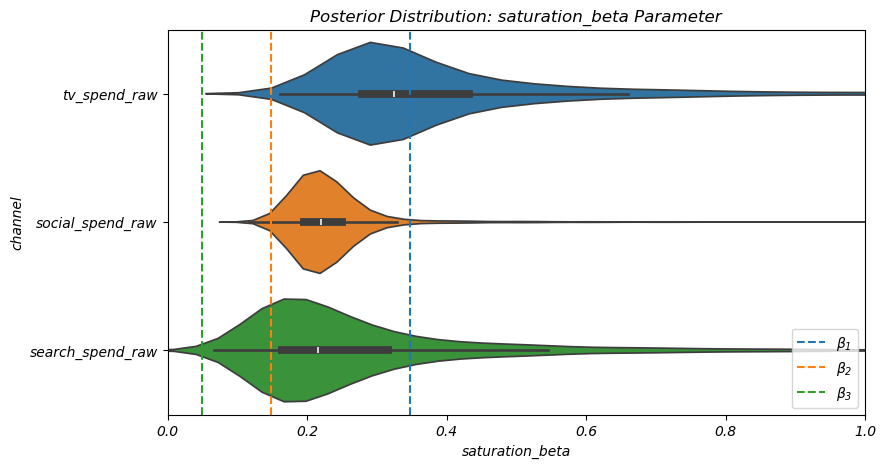

In [76]:

fig = mmm_default.plot_channel_parameter(param_name="saturation_beta", figsize=(9, 5))
ax = fig.axes[0]
ax.axvline(x=betas_scaled[0], color="C0", linestyle="--", label=r"$\beta_1$")
ax.axvline(x=betas_scaled[1], color="C1", linestyle="--", label=r"$\beta_2$")
ax.axvline(x=betas_scaled[2], color="C2", linestyle="--", label=r"$\beta_3$")
ax.set_xlim([0, 1])
ax.legend(loc="lower right");



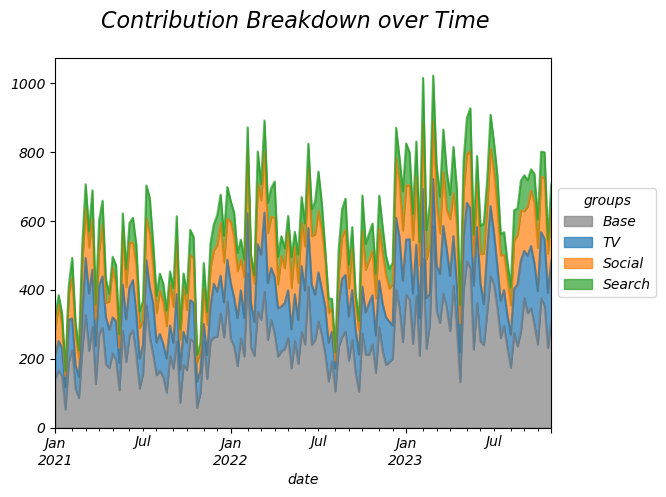

In [77]:


groups = {
    "Base": [
        "intercept",
        "demand_proxy",
    ],
    "TV": ["tv_spend_raw"],
    "Social": ["social_spend_raw"],
    "Search": ["search_spend_raw"],
}

fig = mmm_default.plot_grouped_contribution_breakdown_over_time(
    stack_groups=groups,
    original_scale=True,
    area_kwargs={
        "color": {
            "TV": "C0",
            "Social": "C1",
            "Search": "C2",            
            "Base": "gray",
        },
        "alpha": 0.7,
    },
)

fig.suptitle("Contribution Breakdown over Time", fontsize=16);



In [78]:
channels = np.array(["tv", "social", "search", "demand"])

true_contributions = pd.DataFrame({'Channels': channels, 'Contributions': contributions})
true_contributions= true_contributions.sort_values(by='Contributions', ascending=False).reset_index(drop=True)
true_contributions = true_contributions.style.bar(subset=['Contributions'], color='lightblue')

true_contributions

,Channels,Contributions
0,demand,0.670000
1,tv,0.170000
2,social,0.120000
3,search,0.050000


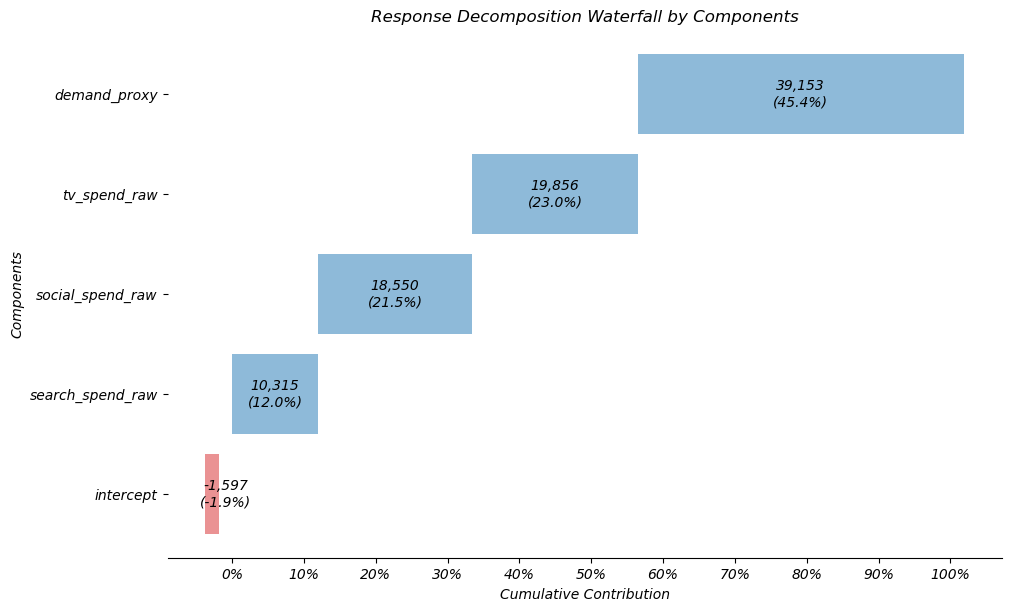

In [79]:
mmm_default.plot_waterfall_components_decomposition(figsize=(10,6));

# MAPE

In [81]:
import numpy as np

def compute_smape(mmm, X_oos, y_actual):
    """
    sMAPE for out-of-sample predictions from a pymc-marketing MMM.
    Returns a float (%).
    """
    ppc = mmm.sample_posterior_predictive(
        X_pred=X_oos,
        extend_idata=False,
        include_last_observations=True,
    )

    y_pred = (
        ppc["y"]
        .to_series()
        .groupby("date")
        .mean()          # collapse posterior draws to point estimate
        .values
    )

    y = np.asarray(y_actual)

    smape = float(
        np.mean(
            2 * np.abs(y - y_pred)
            / (np.abs(y) + np.abs(y_pred))
        ) * 100
    )
    return round(smape, 2)


smape = compute_smape(
    mmm_default,
    X[out_of_time_idx],
    y[out_of_time_idx],
)
print(f"Out-of-sample sMAPE: {smape}%")

Sampling: [y]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Out-of-sample sMAPE: 3.32%


e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


In [83]:
errors = mmm_default.get_errors(original_scale=True)
residuals = errors.mean(("chain", "draw")).values  # correct dims

y_train = y[train_idx].values
y_fitted = y_train - residuals

smape_in = float(
    np.mean(
        2 * np.abs(residuals)
        / (np.abs(y_train) + np.abs(y_fitted))
    ) * 100
)
print(f"In-sample sMAPE: {round(smape_in, 2)}%")

In-sample sMAPE: 4.52%


# channel contribution

In [ ]:
# Get contributions DataFrame
contrib = mmm_default.compute_mean_contributions_over_time(
    original_scale=True   
)
print(contrib.columns.tolist())
print(contrib.head())
# Returns one row per week, one column per component (intercept, each channel, control variables).

['tv_spend_raw', 'social_spend_raw', 'search_spend_raw', 'demand_proxy', 'intercept']
            tv_spend_raw  social_spend_raw  search_spend_raw  demand_proxy  \
date                                                                         
2021-01-03     65.686076         75.693356         39.699094    154.160061   
2021-01-10     85.924848        104.325677         29.053937    176.352934   
2021-01-17     81.297503         65.515787         36.210414    160.087984   
2021-01-24     64.140514         33.418484         14.278500     63.645479   
2021-01-31    121.241020         78.149608         20.933996    202.589688   

            intercept  
date                   
2021-01-03 -10.791486  
2021-01-10 -10.791486  
2021-01-17 -10.791486  
2021-01-24 -10.791486  
2021-01-31 -10.791486  


In [85]:
# Compute percentage shares
total_sales = contrib.sum().sum()

shares = (contrib.sum() / total_sales * 100).round(2)
shares_df = shares.reset_index()
shares_df.columns = ["component", "contribution_%"]
shares_df = shares_df.sort_values("contribution_%", ascending=False)
print(shares_df)


          component  contribution_%
3      demand_proxy           45.38
0      tv_spend_raw           23.01
1  social_spend_raw           21.50
2  search_spend_raw           11.96
4         intercept           -1.85


In [86]:
# Group into Base vs Paid media

base_cols    = ["intercept", "demand_proxy"]
channel_cols = ["tv_spend_raw", "social_spend_raw", "search_spend_raw"]

base_share    = contrib[base_cols].sum().sum()    / total_sales * 100
channel_share = contrib[channel_cols].sum().sum() / total_sales * 100

print(f"Base (organic):  {base_share:.1f}%")
print(f"Paid channels:   {channel_share:.1f}%")

Base (organic):  43.5%
Paid channels:   56.5%


In [97]:
# Validate against the data generator ground truth

true_contributions = {
    "tv":     round(df["tv_sales"].sum()     / df["sales"].sum() * 100, 1),
    "social": round(df["social_sales"].sum() / df["sales"].sum() * 100, 1),
    "search": round(df["search_sales"].sum() / df["sales"].sum() * 100, 1),
    "base":   round(df["demand"].sum()       / df["sales"].sum() * 100, 1),
}
print("True contributions:", true_contributions)

fitted_tv = shares_df.set_index("component").loc["tv_spend_raw", "contribution_%"]
print(f"Model recovered TV: {fitted_tv}%  |  True: {true_contributions['tv']}%")

key_map = {
    "tv_spend_raw":     "tv",
    "social_spend_raw": "social",
    "search_spend_raw": "search",
}

for col, true_key in key_map.items():
    fitted = shares_df.set_index("component").loc[col, "contribution_%"]
    print(f"Model recovered {true_key}: {fitted:.1f}%  |  True: {true_contributions[true_key]}%")


True contributions: {'tv': np.float64(16.7), 'social': np.float64(11.7), 'search': np.float64(4.8), 'base': np.float64(66.8)}
Model recovered TV: 23.01%  |  True: 16.7%
Model recovered tv: 23.0%  |  True: 16.7%
Model recovered social: 21.5%  |  True: 11.7%
Model recovered search: 12.0%  |  True: 4.8%


In [92]:
list(true_contributions.keys())

['tv', 'social', 'search', 'base']

In [98]:
import matplotlib.pyplot as plt
import numpy as np

def plot_contribution_bands(mmm, X, y, date_col="date", original_scale=True):
    """
    Plot channel contributions over time with 94% credible bands.
    Uses the posterior predictive samples already in idata.
    """
    channels = mmm.channel_columns

    fig, axes = plt.subplots(
        len(channels), 1,
        figsize=(12, 3.5 * len(channels)),
        sharex=True
    )

    dates = X[date_col].values

    for ax, ch in zip(axes, channels):
        samples = mmm.sample_posterior_predictive(
            X_pred=X, extend_idata=False, combined=True
        )

        contrib_draws = mmm.get_channel_contributions_forward_pass(
            channel_data=X[[ch]].values,
            combined=True,
            original_scale=original_scale,
        )

        lo  = np.quantile(contrib_draws, 0.03, axis=0)
        mid = np.quantile(contrib_draws, 0.50, axis=0)
        hi  = np.quantile(contrib_draws, 0.97, axis=0)

        ax.fill_between(dates, lo, hi, alpha=0.25, label="94% HDI")
        ax.plot(dates, mid, label="Median")
        ax.set_title(ch, fontsize=12)
        ax.set_ylabel("Sales contribution")
        ax.legend(fontsize=9)

    fig.suptitle("Channel contributions with uncertainty", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

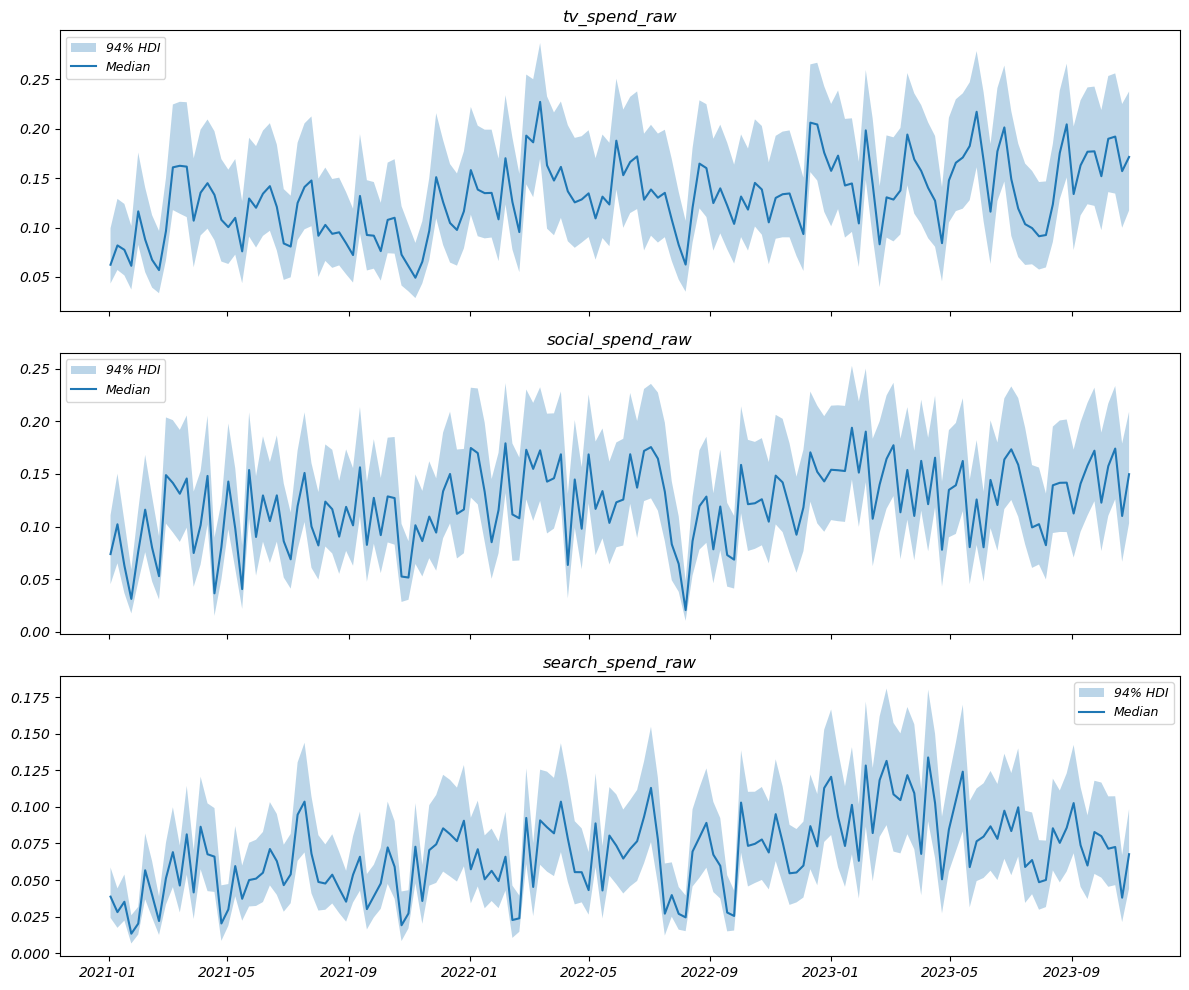

In [100]:
import matplotlib.pyplot as plt
import numpy as np

channels = mmm_default.channel_columns
dates    = X[train_idx]["date"].values

contrib = mmm_default.compute_mean_contributions_over_time(original_scale=True)

fig, axes = plt.subplots(len(channels), 1, figsize=(12, 10), sharex=True)

for ax, ch in zip(axes, channels):
    # posterior draws for this channel from idata
    draws = (
        mmm_default.idata.posterior["channel_contribution"]
        .sel(channel=ch)
        .values
        .reshape(-1, len(dates))          # (chains*draws, weeks)
    )
    lo  = np.quantile(draws, 0.03, axis=0)
    mid = np.quantile(draws, 0.50, axis=0)
    hi  = np.quantile(draws, 0.97, axis=0)

    ax.fill_between(dates, lo, hi, alpha=0.3, label="94% HDI")
    ax.plot(dates, mid, label="Median", linewidth=1.5)
    ax.set_title(ch); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Conclusión:


1. flujo de trabajo MMM con pymc-marketing
1.1 definir las distribuciones previas de los parametros y de las variables
1.2 definir training y testing set
1.3 fit del modelo
1.4 validar el modelo
2. Como se valida el modelo
2.1 checkear divergencias
2.2 vertificar que el Highest Density Interval (HDI) esté por encima de 0 los valores 
2.3 rhat – Gelman-Rubin statistic (mide la convergencia entre las cadenas) sea cercano a 1 (0.95-1.05)
2.4 ess sean mayores a 400
2.5 hacer predicciones y validar con datos reales, verificar que los errores tengan una distribución normal. 
2.6 verificar los errores residuales abs(y_pred - y_act) sean cercanos a 0 o en promedio 0
